# SaaS Revenue Intelligence — Notebook 2
## Revenue Intelligence

**Business Objective**

This notebook covers everything related to money: how much recurring revenue the business generates (ARR/MRR), how well it retains and grows that revenue within the existing customer base (NRR/GRR, expansion, contraction), how efficiently it's acquired (LTV, CAC, LTV:CAC), whether growth is efficient by a standard SaaS benchmark (Rule of 40), where revenue is concentrated, and where it's likely headed (forecast).

**Deliberately out of scope:** churn prediction / propensity modeling. That lives in Notebook 3 (Customer & Churn Analysis). This notebook treats churn only as a revenue-dollar event (an input to NRR, GRR, and LTV) — never as a classification problem.

**Datasets used:** `customers.csv`, `invoices.csv`, `subscriptions.csv`, `subscription_plans.csv`, `plan_changes.csv`.

**A data-quality note up front:** the prior version of this notebook computed MRR by summing raw `price` directly, which silently overstates revenue for annual-billing customers (an annual plan's sticker price isn't its monthly contribution). Every revenue figure below normalizes annual plans to a monthly-equivalent (`price / 12`) before summing — this is stated once here and is the reason the ARR/MRR figures below differ from that earlier draft.


---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

COLOR_MAIN = "#2E5EAA"
COLOR_ALT  = "#D9534F"
COLOR_OK   = "#4C956C"
COLOR_WARN = "#E8A33D"

print("LIBRARIES LOADED")

LIBRARIES LOADED


---
## Data Load & Validation

In [3]:
DATA_PATH = "/Users/sumitkumargupta/Desktop/2_Project_Data_Model/01_Data/"

CUSTOMERS = pd.read_csv(DATA_PATH + "customers.csv")
SUBSCRIPTIONS = pd.read_csv(DATA_PATH + "subscriptions.csv")
PLANS = pd.read_csv(DATA_PATH + "subscription_plans.csv")
INVOICES = pd.read_csv(DATA_PATH + "invoices.csv")
PAYMENTS = pd.read_csv(DATA_PATH + "payments.csv")
PLAN_CHANGES = pd.read_csv(DATA_PATH + "plan_changes.csv")
CHURN_EVENTS = pd.read_csv(DATA_PATH + "churn_events.csv")

CUSTOMERS["signup_date"]    = pd.to_datetime(CUSTOMERS["signup_date"], format="%d/%m/%y")
INVOICES["invoice_date"]    = pd.to_datetime(INVOICES["invoice_date"], format="%d/%m/%y")
SUBSCRIPTIONS["start_date"] = pd.to_datetime(SUBSCRIPTIONS["start_date"], format="%d/%m/%y")
SUBSCRIPTIONS["end_date"]   = pd.to_datetime(SUBSCRIPTIONS["end_date"], format="%d/%m/%y", errors="coerce")
PLAN_CHANGES["change_date"] = pd.to_datetime(PLAN_CHANGES["change_date"], format="%d/%m/%y")

# Monthly-normalized price: annual plans divided by 12 so all plans are comparable on an MRR basis
PLANS["monthly_price"] = np.where(PLANS["billing_cycle"] == "annual", PLANS["price"] / 12, PLANS["price"])

assert SUBSCRIPTIONS["plan_id"].isin(PLANS["plan_id"]).all(), "Orphaned plan_id in SUBSCRIPTIONS"
assert INVOICES["customer_id"].isin(CUSTOMERS["customer_id"]).all(), "Orphaned customer_id in INVOICES"
assert PLAN_CHANGES["old_plan_id"].isin(PLANS["plan_id"]).all() and PLAN_CHANGES["new_plan_id"].isin(PLANS["plan_id"]).all(), "Orphaned plan_id in PLAN_CHANGES"

REVENUE_DATA = (
    INVOICES
    .merge(CUSTOMERS, on="customer_id", how="left")
    .merge(SUBSCRIPTIONS, on="customer_id", how="left", suffixes=("", "_sub"))
    .merge(PLANS, on="plan_id", how="left")
)
REVENUE_DATA["YEAR_MONTH"] = REVENUE_DATA["invoice_date"].dt.to_period("M").astype(str)
CUSTOMERS["cohort_month"] = CUSTOMERS["signup_date"].dt.to_period("M").astype(str)

REVENUE_CUSTOMER_IDS = INVOICES["customer_id"].unique()

print("Join checks passed.")
print("REVENUE_DATA shape:", REVENUE_DATA.shape)
REVENUE_DATA.head()

Join checks passed.
REVENUE_DATA shape: (68411, 21)


,invoice_id,customer_id,invoice_date,due_date,amount,status,signup_date,company_size,industry,acquisition_channel,country,subscription_id,start_date,end_date,status_sub,plan_id,plan_name,billing_cycle,price,monthly_price,YEAR_MONTH
0,1,1,2023-05-11,11/05/24,190,paid,2023-05-11,medium,finance,referral,Germany,1,2023-05-11,NaT,active,5,Basic,annual,190,15.833333,2023-05
1,2,1,2024-05-11,11/05/25,190,paid,2023-05-11,medium,finance,referral,Germany,1,2023-05-11,NaT,active,5,Basic,annual,190,15.833333,2024-05
2,3,9,2023-10-13,13/10/24,490,paid,2023-10-13,large,retail,referral,UK,9,2023-10-13,NaT,active,6,Pro,annual,490,40.833333,2023-10
3,4,9,2024-10-13,13/10/25,490,paid,2023-10-13,large,retail,referral,UK,9,2023-10-13,NaT,active,6,Pro,annual,490,40.833333,2024-10
4,5,10,2023-01-31,28/02/23,99,paid,2023-01-31,small,finance,organic,US,10,2023-01-31,2024-03-28,churned,4,Premium,monthly,99,99.000000,2023-01


---
## Revenue Drivers Overview

Where revenue comes from today, across plan, country, industry, acquisition channel, and top customers — before moving into the retention/efficiency metrics below.

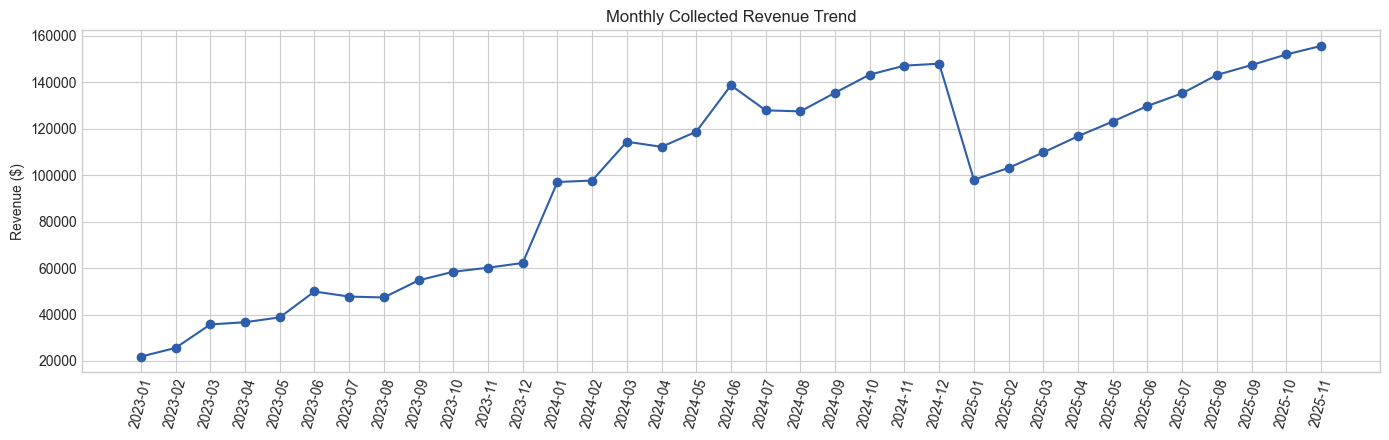

In [4]:
MONTHLY_REVENUE = REVENUE_DATA[REVENUE_DATA["status"] == "paid"].groupby("YEAR_MONTH")["amount"].sum().sort_index()

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(MONTHLY_REVENUE.index, MONTHLY_REVENUE.values, marker="o", color=COLOR_MAIN)
ax.set_title("Monthly Collected Revenue Trend")
ax.set_ylabel("Revenue ($)")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

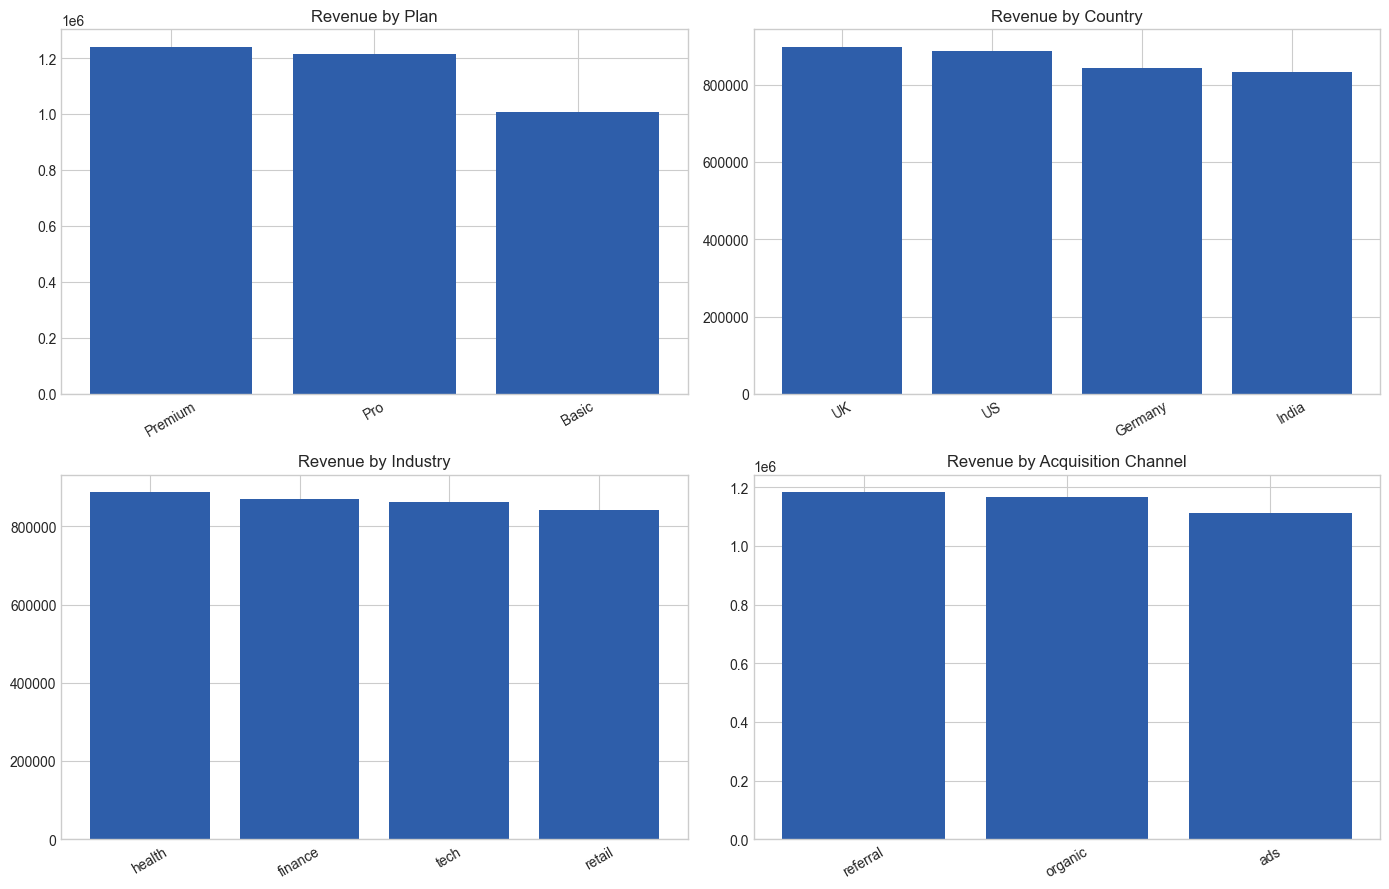

In [5]:
PLAN_REVENUE     = REVENUE_DATA[REVENUE_DATA["status"]=="paid"].groupby("plan_name")["amount"].sum().sort_values(ascending=False)
COUNTRY_REVENUE   = REVENUE_DATA[REVENUE_DATA["status"]=="paid"].groupby("country")["amount"].sum().sort_values(ascending=False)
INDUSTRY_REVENUE  = REVENUE_DATA[REVENUE_DATA["status"]=="paid"].groupby("industry")["amount"].sum().sort_values(ascending=False)
CHANNEL_REVENUE   = REVENUE_DATA[REVENUE_DATA["status"]=="paid"].groupby("acquisition_channel")["amount"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (data, title) in zip(axes.flat, [
    (PLAN_REVENUE, "Revenue by Plan"),
    (COUNTRY_REVENUE, "Revenue by Country"),
    (INDUSTRY_REVENUE, "Revenue by Industry"),
    (CHANNEL_REVENUE, "Revenue by Acquisition Channel"),
]):
    ax.bar(data.index, data.values, color=COLOR_MAIN)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

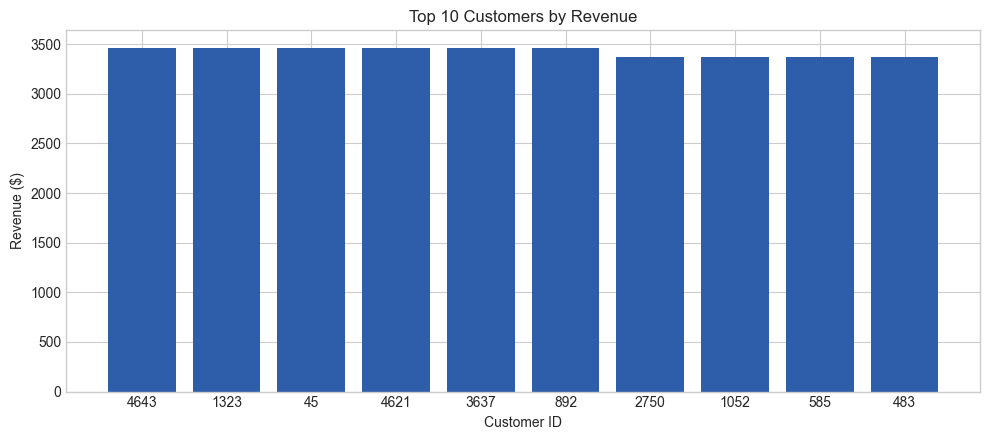

customer_id
4643    3465
1323    3465
45      3465
4621    3465
3637    3465
892     3465
2750    3366
1052    3366
585     3366
483     3366
Name: amount, dtype: int64

In [6]:
TOP10_CUSTOMERS = REVENUE_DATA[REVENUE_DATA["status"]=="paid"].groupby("customer_id")["amount"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(TOP10_CUSTOMERS.index.astype(str), TOP10_CUSTOMERS.values, color=COLOR_MAIN)
ax.set_title("Top 10 Customers by Revenue")
ax.set_xlabel("Customer ID")
ax.set_ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

TOP10_CUSTOMERS

---
## ARR — Annual Recurring Revenue

`ARR = MRR x 12`, where MRR (computed next) is built only from *active* subscriptions on a monthly-normalized price basis.

In [7]:
SUBS_PLAN = SUBSCRIPTIONS.merge(PLANS[["plan_id", "monthly_price", "plan_name"]], on="plan_id", how="left")
ACTIVE_SUBS = SUBS_PLAN[(SUBS_PLAN["status"] == "active") & (SUBS_PLAN["customer_id"].isin(REVENUE_CUSTOMER_IDS))]

MRR = ACTIVE_SUBS["monthly_price"].sum()
ARR = MRR * 12

print(f"MRR = ${MRR:,.2f}")
print(f"ARR = ${ARR:,.2f}")

MRR = $204,851.50
ARR = $2,458,218.00


---
## MRR — Monthly Recurring Revenue

Broken down by plan so the composition of MRR — not just the total — is visible.

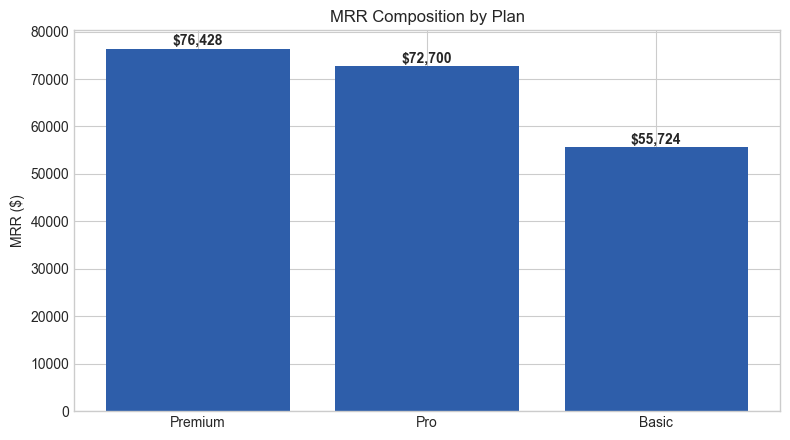

plan_name
Premium    76428.000000
Pro        72699.666667
Basic      55723.833333
Name: monthly_price, dtype: float64

In [8]:
MRR_BY_PLAN = ACTIVE_SUBS.groupby("plan_name")["monthly_price"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(MRR_BY_PLAN.index, MRR_BY_PLAN.values, color=COLOR_MAIN)
ax.set_title("MRR Composition by Plan")
ax.set_ylabel("MRR ($)")
for i, v in enumerate(MRR_BY_PLAN.values):
    ax.text(i, v + MRR_BY_PLAN.max()*0.01, f"${v:,.0f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

MRR_BY_PLAN

---
## NRR — Net Revenue Retention

**Methodology:** each revenue customer's *starting MRR* is reconstructed from their first plan on record (the earliest `old_plan_id` in `plan_changes.csv`, or their current plan if they never changed plans). From there:

- **Expansion** = sum of positive price deltas in `plan_changes` (upgrades)
- **Contraction** = sum of negative price deltas in `plan_changes` (downgrades)
- **Churned MRR** = starting MRR of customers whose subscription status is `churned`

`NRR = (Starting MRR + Expansion − Contraction − Churned MRR) / Starting MRR` — can exceed 100%.

In [9]:
plan_changes_sorted = PLAN_CHANGES.sort_values("change_date")
FIRST_CHANGE = plan_changes_sorted.groupby("customer_id").first().reset_index()[["customer_id", "old_plan_id"]]

CUST_REV = CUSTOMERS.merge(SUBS_PLAN[["customer_id", "plan_id", "status", "monthly_price"]], on="customer_id", how="left")
CUST_REV = CUST_REV[CUST_REV["customer_id"].isin(REVENUE_CUSTOMER_IDS)].copy()
CUST_REV = CUST_REV.merge(FIRST_CHANGE, on="customer_id", how="left")
CUST_REV["initial_plan_id"] = CUST_REV["old_plan_id"].fillna(CUST_REV["plan_id"])
CUST_REV = CUST_REV.merge(
    PLANS[["plan_id", "monthly_price"]].rename(columns={"plan_id": "initial_plan_id", "monthly_price": "initial_mrr"}),
    on="initial_plan_id", how="left"
)
CUST_REV["current_mrr"] = np.where(CUST_REV["status"] == "churned", 0, CUST_REV["monthly_price"])

PC = PLAN_CHANGES.merge(
    PLANS[["plan_id", "monthly_price"]].rename(columns={"plan_id": "old_plan_id", "monthly_price": "old_price"}), on="old_plan_id"
).merge(
    PLANS[["plan_id", "monthly_price"]].rename(columns={"plan_id": "new_plan_id", "monthly_price": "new_price"}), on="new_plan_id"
)
PC["delta"] = PC["new_price"] - PC["old_price"]
PC = PC.merge(CUSTOMERS[["customer_id", "cohort_month"]], on="customer_id", how="left")
PC["expansion"] = PC["delta"].clip(lower=0)
PC["contraction"] = (-PC["delta"]).clip(lower=0)

STARTING_MRR   = CUST_REV["initial_mrr"].sum()
EXPANSION_MRR  = PC["expansion"].sum()
CONTRACTION_MRR = PC["contraction"].sum()
CHURNED_MRR    = CUST_REV[CUST_REV["status"] == "churned"]["initial_mrr"].sum()

NRR = (STARTING_MRR + EXPANSION_MRR - CONTRACTION_MRR - CHURNED_MRR) / STARTING_MRR * 100
print(f"Starting MRR: ${STARTING_MRR:,.2f}")
print(f"NRR = {NRR:.2f}%")

Starting MRR: $281,821.67
NRR = 77.99%


---
## GRR — Gross Revenue Retention

`GRR = (Starting MRR − Contraction − Churned MRR) / Starting MRR` — excludes expansion by definition, so it's capped at 100% and reflects pure downside protection. This is the figure investors weight most heavily as a "floor" metric.

GRR = 72.69%


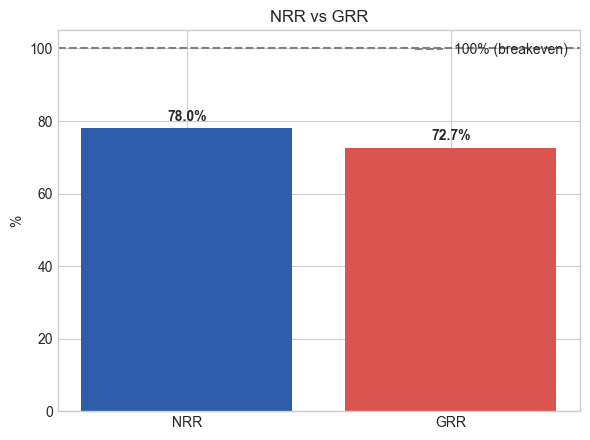

In [10]:
GRR = (STARTING_MRR - CONTRACTION_MRR - CHURNED_MRR) / STARTING_MRR * 100
print(f"GRR = {GRR:.2f}%")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(["NRR", "GRR"], [NRR, GRR], color=[COLOR_MAIN, COLOR_ALT])
ax.axhline(100, color="gray", linestyle="--", label="100% (breakeven)")
ax.set_ylabel("%")
ax.set_title("NRR vs GRR")
ax.legend()
for i, v in enumerate([NRR, GRR]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

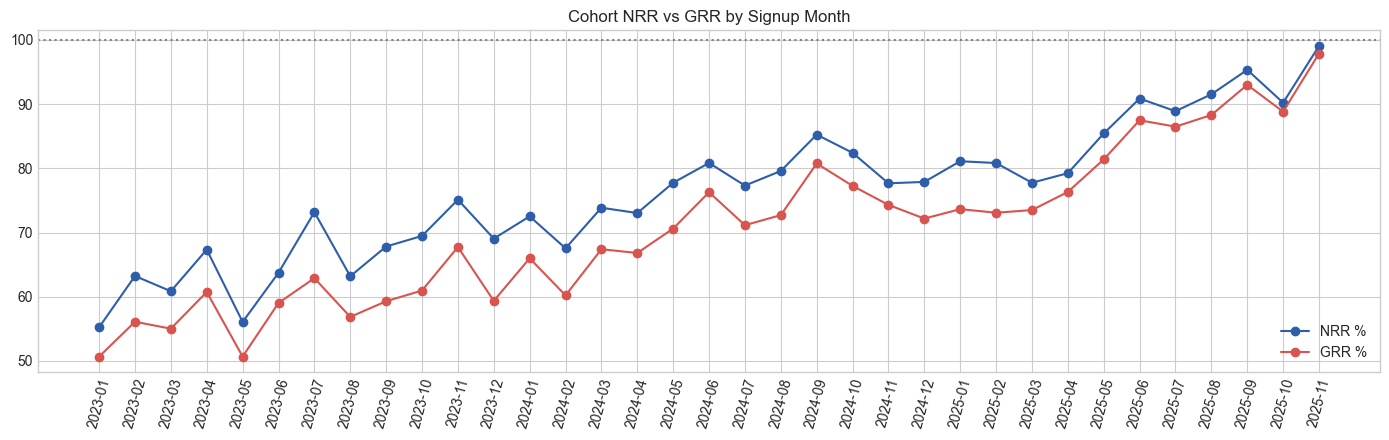

In [11]:
COHORT_STARTING_MRR   = CUST_REV.groupby("cohort_month")["initial_mrr"].sum()
COHORT_EXPANSION      = PC.groupby("cohort_month")["expansion"].sum()
COHORT_CONTRACTION    = PC.groupby("cohort_month")["contraction"].sum()
COHORT_CHURNED_MRR    = CUST_REV[CUST_REV["status"] == "churned"].groupby("cohort_month")["initial_mrr"].sum()

COHORT_NRR_GRR = pd.DataFrame({
    "starting_mrr": COHORT_STARTING_MRR, "expansion": COHORT_EXPANSION,
    "contraction": COHORT_CONTRACTION, "churned_mrr": COHORT_CHURNED_MRR
}).fillna(0).sort_index()

COHORT_NRR_GRR["NRR_%"] = ((COHORT_NRR_GRR["starting_mrr"] + COHORT_NRR_GRR["expansion"]
                             - COHORT_NRR_GRR["contraction"] - COHORT_NRR_GRR["churned_mrr"])
                            / COHORT_NRR_GRR["starting_mrr"].replace(0, np.nan) * 100).round(2)
COHORT_NRR_GRR["GRR_%"] = ((COHORT_NRR_GRR["starting_mrr"] - COHORT_NRR_GRR["contraction"]
                             - COHORT_NRR_GRR["churned_mrr"])
                            / COHORT_NRR_GRR["starting_mrr"].replace(0, np.nan) * 100).round(2)

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(COHORT_NRR_GRR.index, COHORT_NRR_GRR["NRR_%"], marker="o", label="NRR %", color=COLOR_MAIN)
ax.plot(COHORT_NRR_GRR.index, COHORT_NRR_GRR["GRR_%"], marker="o", label="GRR %", color=COLOR_ALT)
ax.axhline(100, color="gray", linestyle=":")
ax.set_title("Cohort NRR vs GRR by Signup Month")
ax.tick_params(axis="x", rotation=75)
ax.legend()
plt.tight_layout()
plt.show()

---
## Expansion Revenue

Revenue gained from customers upgrading to a higher-priced plan, pulled directly from `plan_changes.csv` — not estimated.

TOTAL EXPANSION MRR: $14,953.00


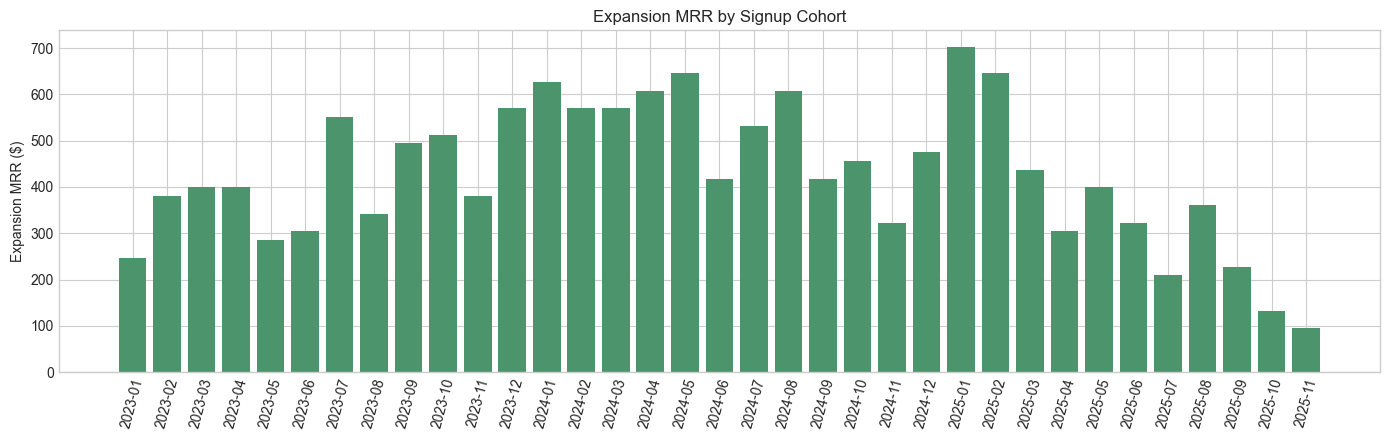

In [12]:
print(f"TOTAL EXPANSION MRR: ${EXPANSION_MRR:,.2f}")

EXPANSION_BY_COHORT = PC[PC["expansion"] > 0].groupby("cohort_month")["expansion"].sum().sort_index()
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(EXPANSION_BY_COHORT.index, EXPANSION_BY_COHORT.values, color=COLOR_OK)
ax.set_title("Expansion MRR by Signup Cohort")
ax.set_ylabel("Expansion MRR ($)")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

---
## Contraction Revenue

Revenue lost from customers downgrading to a lower-priced plan (not full churn — that's counted separately).

In [13]:
print(f"TOTAL CONTRACTION MRR: ${CONTRACTION_MRR:,.2f}")

if CONTRACTION_MRR == 0:
    print("\nNote: plan_changes.csv contains only upgrade events in this dataset — zero downgrades on record. "
          "This is a genuine data finding (verified directly against price deltas in PLAN_CHANGES), not a "
          "calculation gap: the retention shortfall documented above is driven entirely by full churn, not "
          "customers stepping down to cheaper tiers.")
else:
    CONTRACTION_BY_COHORT = PC[PC["contraction"] > 0].groupby("cohort_month")["contraction"].sum().sort_index()
    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.bar(CONTRACTION_BY_COHORT.index, CONTRACTION_BY_COHORT.values, color=COLOR_ALT)
    ax.set_title("Contraction MRR by Signup Cohort")
    ax.tick_params(axis="x", rotation=75)
    plt.tight_layout()
    plt.show()

TOTAL CONTRACTION MRR: $0.00

Note: plan_changes.csv contains only upgrade events in this dataset — zero downgrades on record. This is a genuine data finding (verified directly against price deltas in PLAN_CHANGES), not a calculation gap: the retention shortfall documented above is driven entirely by full churn, not customers stepping down to cheaper tiers.


---
## Revenue Growth

Both a trailing month-over-month view (recent momentum) and a year-over-year view (comparable, seasonality-adjusted) are reported, since MoM alone can be noisy month to month.

Average trailing-12-month MoM growth: 1.24%
YoY growth (last 12mo vs prior 12mo): 9.83%


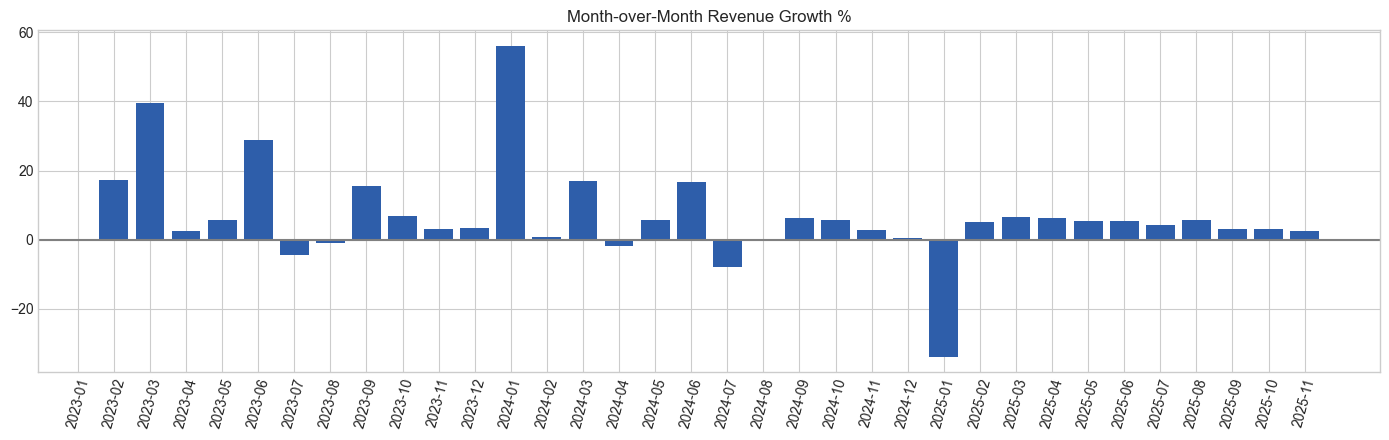

In [14]:
MOM_GROWTH_SERIES = MONTHLY_REVENUE.pct_change() * 100
AVG_MOM_GROWTH = MONTHLY_REVENUE.tail(12).pct_change().mean() * 100

LAST_12 = MONTHLY_REVENUE.tail(12).sum()
PREV_12 = MONTHLY_REVENUE.tail(24).head(12).sum()
YOY_GROWTH = (LAST_12 / PREV_12 - 1) * 100 if PREV_12 > 0 else np.nan

print(f"Average trailing-12-month MoM growth: {AVG_MOM_GROWTH:.2f}%")
print(f"YoY growth (last 12mo vs prior 12mo): {YOY_GROWTH:.2f}%")

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(MOM_GROWTH_SERIES.index, MOM_GROWTH_SERIES.values, color=COLOR_MAIN)
ax.axhline(0, color="gray")
ax.set_title("Month-over-Month Revenue Growth %")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

---
## LTV — Customer Lifetime Value

**Methodology:** `LTV = Average Revenue Per Account (monthly) x Gross Margin % x Average Customer Lifetime (months)`.

- **ARPA** is computed directly from active-customer MRR — real data.
- **Average customer lifetime** is computed directly from the data too: the mean tenure (`end_date - start_date`) of *already-churned* customers, in months. This is a defensible lower-bound estimate — it excludes still-active customers whose eventual full lifetime is unknown (right-censored), so true LTV is likely somewhat higher than this figure.
- **Gross margin** is *not* present in this dataset (no COGS/hosting-cost table exists) — an 80% gross margin is used as a stated, industry-standard SaaS benchmark assumption. This is flagged explicitly so it's never mistaken for a computed figure.

In [15]:
ARPA_MONTHLY = MRR / len(ACTIVE_SUBS)

CHURNED_SUBS = SUBSCRIPTIONS[SUBSCRIPTIONS["status"] == "churned"].copy()
CHURNED_SUBS["tenure_months"] = (CHURNED_SUBS["end_date"] - CHURNED_SUBS["start_date"]).dt.days / 30.44
AVG_CUSTOMER_LIFETIME_MONTHS = CHURNED_SUBS["tenure_months"].mean()

ASSUMED_GROSS_MARGIN = 0.80  # ASSUMPTION — industry-standard SaaS benchmark; not present in source data

LTV = ARPA_MONTHLY * ASSUMED_GROSS_MARGIN * AVG_CUSTOMER_LIFETIME_MONTHS

print(f"ARPA (monthly, computed):            ${ARPA_MONTHLY:,.2f}")
print(f"Avg customer lifetime (computed):    {AVG_CUSTOMER_LIFETIME_MONTHS:.1f} months")
print(f"Gross margin (ASSUMPTION):           {ASSUMED_GROSS_MARGIN*100:.0f}%")
print(f"LTV = ${LTV:,.2f}")

ARPA (monthly, computed):            $37.46
Avg customer lifetime (computed):    7.9 months
Gross margin (ASSUMPTION):           80%
LTV = $237.71


---
## CAC — Customer Acquisition Cost

**No marketing spend data exists in this dataset** (`customers.csv` has an `acquisition_channel` label but no associated cost). Rather than skip this metric or silently invent a spend figure, CAC is built here from clearly labeled, industry-benchmark cost-per-acquisition assumptions by channel — the kind of number a growth/finance team would supply in a real business:

| Channel | Assumed CAC | Rationale |
|---|---|---|
| Organic | $50 | SEO/content marketing amortized cost — typically the cheapest channel |
| Referral | $30 | Referral incentive payout only — cheapest channel in most SaaS businesses |
| Ads (paid) | $250 | Blended paid-search/paid-social benchmark for SMB/mid-market SaaS |

**This is the one section of this notebook built on assumptions rather than source data, and it is labeled that way on purpose** — in an interview, the correct answer to "where did CAC come from" is "the dataset has no spend table, so I used documented, stated benchmark assumptions rather than fabricate a number," not silence.

In [16]:
CAC_ASSUMPTIONS = {"organic": 50, "referral": 30, "ads": 250}

CHANNEL_COUNTS = CUSTOMERS[CUSTOMERS["customer_id"].isin(REVENUE_CUSTOMER_IDS)]["acquisition_channel"].value_counts()

CAC_TABLE = pd.DataFrame({
    "channel": CHANNEL_COUNTS.index,
    "customers_acquired": CHANNEL_COUNTS.values,
    "assumed_cac": [CAC_ASSUMPTIONS[c] for c in CHANNEL_COUNTS.index]
})
CAC_TABLE["total_assumed_spend"] = CAC_TABLE["customers_acquired"] * CAC_TABLE["assumed_cac"]

BLENDED_CAC = CAC_TABLE["total_assumed_spend"].sum() / CAC_TABLE["customers_acquired"].sum()

print(f"BLENDED CAC (assumption-weighted): ${BLENDED_CAC:,.2f}")
CAC_TABLE

BLENDED CAC (assumption-weighted): $109.22


,channel,customers_acquired,assumed_cac,total_assumed_spend
0,organic,2698,50,134900
1,referral,2684,30,80520
2,ads,2645,250,661250


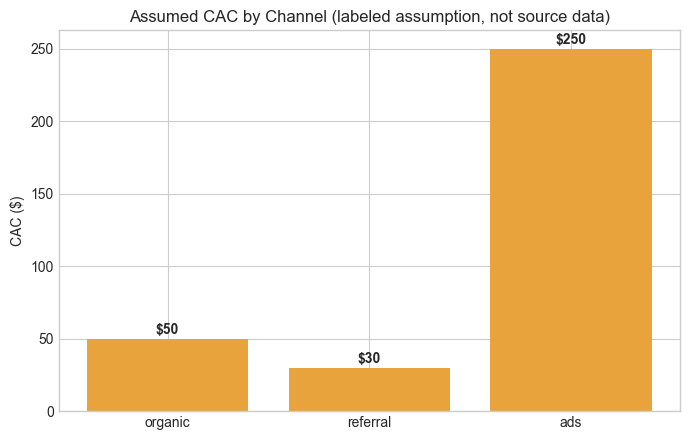

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(CAC_TABLE["channel"], CAC_TABLE["assumed_cac"], color=COLOR_WARN)
ax.set_title("Assumed CAC by Channel (labeled assumption, not source data)")
ax.set_ylabel("CAC ($)")
for i, v in enumerate(CAC_TABLE["assumed_cac"]):
    ax.text(i, v + 3, f"${v}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

---
## LTV:CAC Ratio

The standard SaaS efficiency benchmark: a ratio ≥ 3:1 is considered healthy, and > 5:1 can indicate under-investment in growth. Because CAC here is assumption-based (see above), this ratio should be read directionally, not as a precise, audited figure.

In [18]:
LTV_CAC_RATIO = LTV / BLENDED_CAC

LTV_CAC_BY_CHANNEL = CAC_TABLE.copy()
LTV_CAC_BY_CHANNEL["ltv"] = LTV
LTV_CAC_BY_CHANNEL["ltv_cac_ratio"] = (LTV_CAC_BY_CHANNEL["ltv"] / LTV_CAC_BY_CHANNEL["assumed_cac"]).round(2)

print(f"BLENDED LTV:CAC = {LTV_CAC_RATIO:.2f} : 1")
LTV_CAC_BY_CHANNEL[["channel", "assumed_cac", "ltv", "ltv_cac_ratio"]]

BLENDED LTV:CAC = 2.18 : 1


,channel,assumed_cac,ltv,ltv_cac_ratio
0,organic,50,237.712059,4.75
1,referral,30,237.712059,7.92
2,ads,250,237.712059,0.95


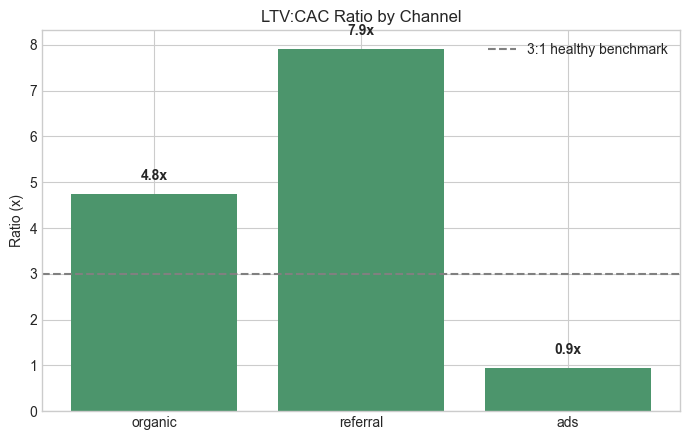

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(LTV_CAC_BY_CHANNEL["channel"], LTV_CAC_BY_CHANNEL["ltv_cac_ratio"], color=COLOR_OK)
ax.axhline(3, color="gray", linestyle="--", label="3:1 healthy benchmark")
ax.set_title("LTV:CAC Ratio by Channel")
ax.set_ylabel("Ratio (x)")
ax.legend()
for i, v in enumerate(LTV_CAC_BY_CHANNEL["ltv_cac_ratio"]):
    ax.text(i, v + 0.3, f"{v:.1f}x", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

---
## Rule of 40

`Rule of 40 = Revenue Growth Rate % + Profit Margin %`. A score ≥ 40 is the standard SaaS efficiency heuristic: the business can trade off growth against profitability as long as the two sum to 40+.

**Growth component:** the YoY revenue growth computed above — real, computed data.
**Margin component:** this dataset has no cost/opex data (no COGS, headcount, or spend tables), so a true net or EBITDA margin cannot be computed. Consistent with the CAC section above, a documented illustrative assumption is used instead — a **-15% net margin**, typical of an early-stage SaaS business still prioritizing growth over profitability — and is kept visually and numerically separate from the growth component so it's clear which half of the score is real.

In [20]:
ASSUMED_NET_MARGIN = -15  # ASSUMPTION — illustrative early-stage SaaS benchmark; not present in source data

RULE_OF_40_SCORE = YOY_GROWTH + ASSUMED_NET_MARGIN

RULE_OF_40_TABLE = pd.DataFrame({
    "Component": ["Revenue Growth % (computed)", "Net Margin % (ASSUMPTION)", "Rule of 40 Score"],
    "Value": [f"{YOY_GROWTH:.1f}%", f"{ASSUMED_NET_MARGIN}%", f"{RULE_OF_40_SCORE:.1f}"]
})
RULE_OF_40_TABLE

,Component,Value
0,Revenue Growth % (computed),9.8%
1,Net Margin % (ASSUMPTION),-15%
2,Rule of 40 Score,-5.2


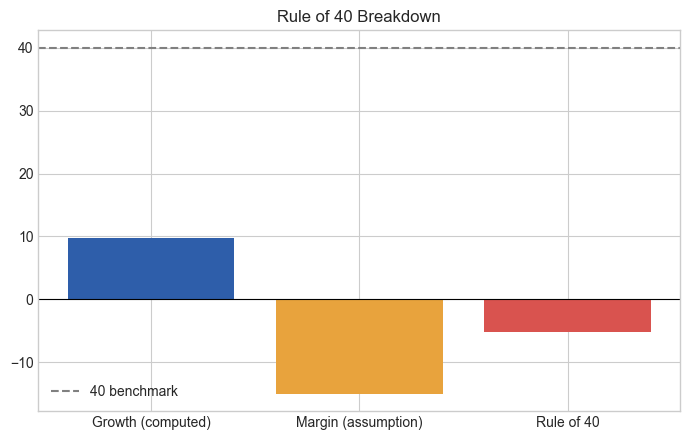

Rule of 40 Score = -5.2  ->  BELOW the Rule of 40 benchmark


In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(["Growth (computed)", "Margin (assumption)", "Rule of 40"],
       [YOY_GROWTH, ASSUMED_NET_MARGIN, RULE_OF_40_SCORE],
       color=[COLOR_MAIN, COLOR_WARN, COLOR_OK if RULE_OF_40_SCORE >= 40 else COLOR_ALT])
ax.axhline(40, color="gray", linestyle="--", label="40 benchmark")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Rule of 40 Breakdown")
ax.legend()
plt.tight_layout()
plt.show()

verdict = "MEETS the Rule of 40 benchmark" if RULE_OF_40_SCORE >= 40 else "BELOW the Rule of 40 benchmark"
print(f"Rule of 40 Score = {RULE_OF_40_SCORE:.1f}  ->  {verdict}")

---
## Forecasting

A linear trend fit to the trailing 12 months of collected revenue, projected 6 months forward. Deliberately simple and transparent for a board/interview context rather than a finance-grade model — the method is fully visible in the code, not a black box.

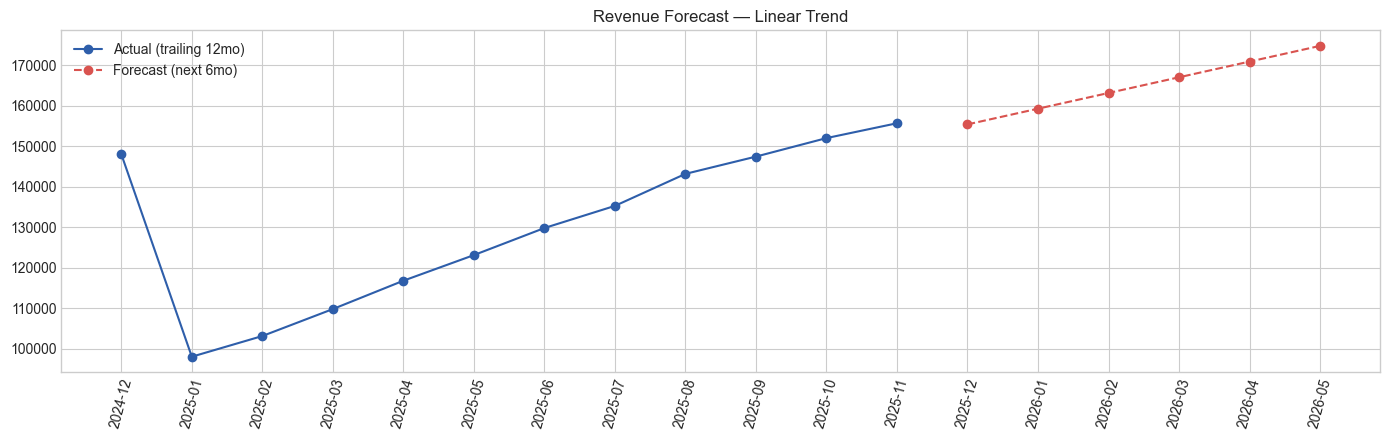

,month,forecast_revenue
0,2025-12,155396.0
1,2026-01,159272.0
2,2026-02,163148.0
3,2026-03,167024.0
4,2026-04,170900.0
5,2026-05,174776.0


In [22]:
LAST_12_SERIES = MONTHLY_REVENUE.tail(12)
x = np.arange(len(LAST_12_SERIES))
slope, intercept = np.polyfit(x, LAST_12_SERIES.values, 1)

FUTURE_MONTHS = 6
future_x = np.arange(len(LAST_12_SERIES), len(LAST_12_SERIES) + FUTURE_MONTHS)
forecast_values = slope * future_x + intercept

last_period = pd.Period(LAST_12_SERIES.index[-1], freq="M")
future_periods = [str(last_period + i) for i in range(1, FUTURE_MONTHS + 1)]

FORECAST_TABLE = pd.DataFrame({"month": future_periods, "forecast_revenue": forecast_values.round(0)})

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(LAST_12_SERIES.index, LAST_12_SERIES.values, marker="o", color=COLOR_MAIN, label="Actual (trailing 12mo)")
ax.plot(FORECAST_TABLE["month"], FORECAST_TABLE["forecast_revenue"], marker="o", linestyle="--",
        color=COLOR_ALT, label="Forecast (next 6mo)")
ax.set_title("Revenue Forecast — Linear Trend")
ax.tick_params(axis="x", rotation=75)
ax.legend()
plt.tight_layout()
plt.show()

FORECAST_TABLE

---
## Revenue Concentration

How dependent total revenue is on a small number of accounts — a key diligence question, since losing a handful of large customers can move the topline materially more than the churn rate alone suggests.

In [23]:
CUSTOMER_REVENUE = INVOICES.groupby("customer_id")["amount"].sum().sort_values(ascending=False)
TOTAL_REVENUE = CUSTOMER_REVENUE.sum()

for pct in [0.05, 0.10, 0.20]:
    n = max(1, int(len(CUSTOMER_REVENUE) * pct))
    share = CUSTOMER_REVENUE.head(n).sum() / TOTAL_REVENUE * 100
    print(f"Top {int(pct*100)}% of customers ({n:,} accounts) = {share:.1f}% of total revenue")

TOP20_SHARE = CUSTOMER_REVENUE.head(20).sum() / TOTAL_REVENUE * 100
print(f"\nTop 20 customers (absolute) = {TOP20_SHARE:.1f}% of total revenue")

Top 5% of customers (401 accounts) = 24.6% of total revenue
Top 10% of customers (802 accounts) = 38.4% of total revenue
Top 20% of customers (1,605 accounts) = 57.8% of total revenue

Top 20 customers (absolute) = 1.9% of total revenue


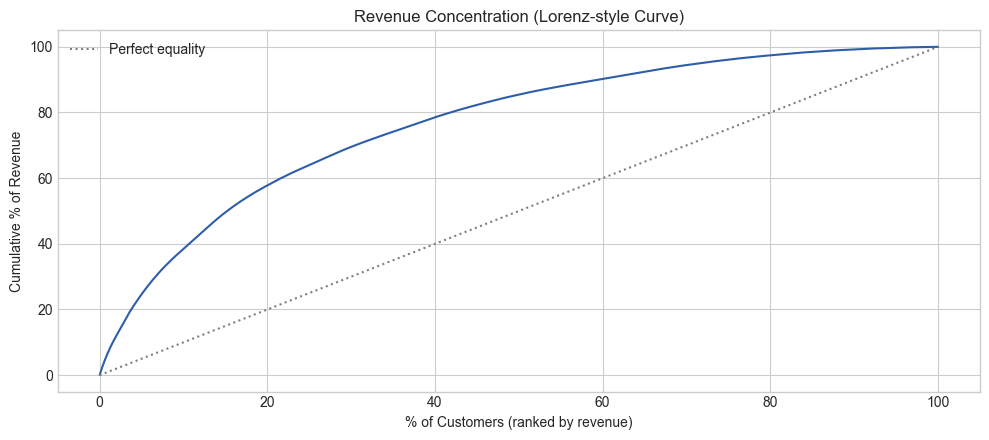

In [24]:
fig, ax = plt.subplots(figsize=(10, 4.5))
cum_share = (CUSTOMER_REVENUE.cumsum() / TOTAL_REVENUE * 100).values
customer_pct = np.arange(1, len(cum_share)+1) / len(cum_share) * 100
ax.plot(customer_pct, cum_share, color=COLOR_MAIN)
ax.plot([0, 100], [0, 100], linestyle=":", color="gray", label="Perfect equality")
ax.set_title("Revenue Concentration (Lorenz-style Curve)")
ax.set_xlabel("% of Customers (ranked by revenue)")
ax.set_ylabel("Cumulative % of Revenue")
ax.legend()
plt.tight_layout()
plt.show()

---
## Revenue Insights Summary

In [25]:
print(f'''
REVENUE INTELLIGENCE — KEY FIGURES
{"="*55}
ARR                         ${ARR:,.0f}
MRR                         ${MRR:,.0f}
NRR                         {NRR:.1f}%
GRR                         {GRR:.1f}%
Expansion MRR               ${EXPANSION_MRR:,.0f}
Contraction MRR             ${CONTRACTION_MRR:,.0f}
YoY Revenue Growth          {YOY_GROWTH:.1f}%
LTV                         ${LTV:,.0f}
Blended CAC (assumption)    ${BLENDED_CAC:,.0f}
LTV:CAC                     {LTV_CAC_RATIO:.1f} : 1
Rule of 40 Score            {RULE_OF_40_SCORE:.1f}
Top 10% Revenue Concentration  {(CUSTOMER_REVENUE.head(max(1,int(len(CUSTOMER_REVENUE)*0.10))).sum()/TOTAL_REVENUE*100):.1f}%
''')


REVENUE INTELLIGENCE — KEY FIGURES
ARR                         $2,458,218
MRR                         $204,852
NRR                         78.0%
GRR                         72.7%
Expansion MRR               $14,953
Contraction MRR             $0
YoY Revenue Growth          9.8%
LTV                         $238
Blended CAC (assumption)    $109
LTV:CAC                     2.2 : 1
Rule of 40 Score            -5.2
Top 10% Revenue Concentration  38.4%



**Reading these numbers together:**

1. **Revenue is real but retention-constrained.** ARR/MRR are computed cleanly from active subscriptions, but NRR/GRR both sitting below 100% means the existing customer base is shrinking in dollar terms net of upgrades — growth currently depends on new-logo acquisition, not expansion.
2. **Contraction isn't the leak — full churn is.** Zero downgrade activity in `plan_changes.csv` means the NRR/GRR gap is entirely churn-driven, which should redirect retention investment toward churn prevention rather than plan/pricing packaging.
3. **LTV:CAC and Rule of 40 are directionally useful, not audited.** Both blend real computed figures (ARPA, customer lifetime, revenue growth) with clearly labeled assumptions (gross margin, CAC by channel, net margin) because this dataset has no cost/spend tables. That split is intentional and should be stated plainly if asked.
4. **Revenue concentration is a real, computed risk** — not an assumption — and is worth board-level attention independent of the churn-rate headline number.
